In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
import scipy.io
import matplotlib.pyplot as plt
import os
import sys

sys.path.append('../../STACAME/')

import STACAME

import warnings
warnings.filterwarnings("ignore")

os.environ["CUDA_VISIBLE_DEVICES"] = "1"

/mnt/disk1/zhangbiao/anaconda3/envs/env_stitch3d/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/mnt/disk1/zhangbiao/anaconda3/envs/env_stitch3d/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:


data_path =  '../Data/Mouse/'
section_name_list = ['Mouse1_T167', 'Mouse1_T168', 'Mouse1_T169', 'Mouse1_T170',
                    'Mouse1_T171', 'Mouse1_T172', 'Mouse1_T173', 'Mouse1_T174', 
                    'Mouse1_T175', 'Mouse1_T176', 'Mouse1_T177', 'Mouse1_T178',
                    'Mouse1_T179', 'Mouse1_T180', 'Mouse1_T181', 'Mouse1_T182',
                    'Mouse1_T183', 'Mouse1_T184', 'Mouse1_T185', 'Mouse1_T186',
                    'Mouse1_T187', 'Mouse1_T188', 'Mouse1_T189', 'Mouse1_T190',
                    'Mouse1_T191', 'Mouse1_T192', 'Mouse1_T193', 'Mouse1_T194',
                    'Mouse1_T195', 'Mouse1_T196', 'Mouse1_T197', 'Mouse1_T198'] 
# section_name_list = ['Mouse1_T167', 'Mouse1_T168', 'Mouse1_T169', 'Mouse1_T170',
#                     'Mouse1_T171', 'Mouse1_T172', 'Mouse1_T173', 'Mouse1_T174'] 
# #                     'Mouse1_T175', 'Mouse1_T176', 'Mouse1_T177', 'Mouse1_T178',] #, 
sect_dict = {}
adata_raw_list = []
for section_name in section_name_list:
    save_section_name = section_name
    section_name = section_name + '.h5ad'
    adata = sc.read_h5ad(data_path + section_name)
    print(adata)
    adata.obs['batch_name'] = save_section_name
    adata.obs['slice_name'] = save_section_name
    adata.obs['slice'] = save_section_name
    adata.obs['species_id'] = 'Mouse'
    adata.obs['region_name'] = adata.obs['annotation']
    adata.obsm['loc_use'] = adata.obsm['spatial'] 
    adata.obs['array_row'] = adata.obsm['spatial'][:, 0]
    adata.obs['array_col'] = adata.obsm['spatial'][:, 1]
    adata_raw_list.append(adata)
    print(type(adata.X))
    sect_dict[save_section_name  + '_load'] = adata.n_obs
    #adata.write_h5ad(data_path + save_section_name  + '_load' + '.h5ad')

mouse_sect_names = list(sect_dict.keys())


AnnData object with n_obs × n_vars = 18548 × 21481
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'region', 'coor_x', 'coor_y', 'raw_x', 'raw_y', 'distance', 'area', 'Astrocyte', 'Bergmann', 'Choroid', 'Endothelial_mural', 'Endothelial_stalk', 'Ependymal', 'Fibroblast', 'Golgi', 'Granule', 'MLI1', 'MLI2', 'Macrophage', 'Microglia', 'ODC', 'OPC', 'PLI', 'Purkinje', 'UBC', 'cluster', 'annotation'
    var: 'geneID', 'features'
    uns: 'annotation_colors'
    obsm: 'spatial'
<class 'scipy.sparse._csr.csr_matrix'>
AnnData object with n_obs × n_vars = 25746 × 22063
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'region', 'coor_x', 'coor_y', 'raw_x', 'raw_y', 'distance', 'area', 'Astrocyte', 'Bergmann', 'Choroid', 'Endothelial_mural', 'Endothelial_stalk', 'Ependymal', 'Fibroblast', 'Golgi', 'Granule', 'MLI1', 'MLI2', 'Macrophage', 'Microglia', 'ODC', 'OPC', 'PLI', 'Purkinje', 'UBC', 'cluster', 'annotation'
    var: 'geneID', 'features'
    uns: 'annotation_colors'
    obsm: 'spat

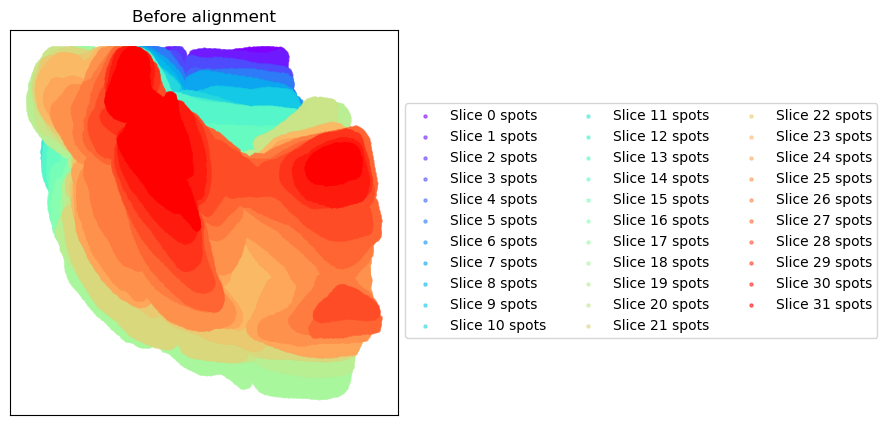

Using the Iterative Closest Point algorithm for alignemnt.
Detecting edges...
Aligning edges...


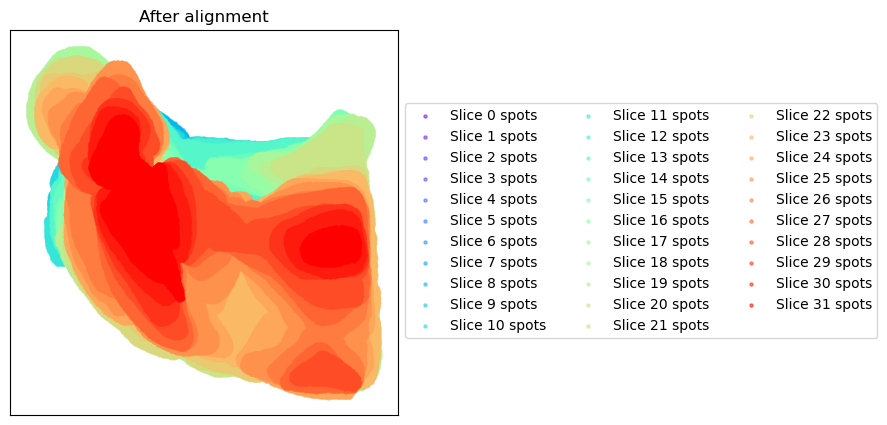

In [3]:
adata_st_list = STACAME.align_spots(adata_raw_list,
                                           plot=True,
                                           data_type="Stereo-seq",
                                           coor_key="spatial",
                                           method= 'icp',
                                           test_all_angles=False,
                                           subsampling = True,
                                           subsampling_rate = 0.05)

In [4]:
import numpy as np
import scanpy as sc
import anndata as ad
import pandas as pd
import scipy.sparse
import matplotlib
import matplotlib.pyplot as plt
from STACAME.align_tools import *
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import pairwise_distances
from matplotlib import cm

In [5]:
mouse_df = pd.read_csv('../Data/slicedistance/Mouse.csv')
print(mouse_df)
mouse_df = mouse_df.set_index('Slice')
print(mouse_df.loc['T167', :])

slice_distance_list = []
for section_name in section_name_list:
    name = section_name.split('_')[1]
    slice_distance_list.append(mouse_df.loc[name, :].values[0])

print(slice_distance_list)

# Mouse: resolution - 100um
slice_distance_list = [x * 1000/100 for x in slice_distance_list]
slice_dist_micron = [slice_distance_list[i+1] - slice_distance_list[i] for i in range(0, len(slice_distance_list)-1)]

   Slice  EBZ (mm)
0   T167     -7.62
1   T168     -7.51
2   T169     -7.36
3   T170     -7.28
4   T171     -7.16
..   ...       ...
56  T369     -6.89
57  T370     -6.99
58  T371     -7.08
59  T372     -7.18
60  T373     -7.28

[61 rows x 2 columns]
EBZ (mm)   -7.62
Name: T167, dtype: float64
[-7.62, -7.51, -7.36, -7.28, -7.16, -7.25, -7.08, -7.0, -6.85, -6.78, -6.66, -6.58, -6.44, -6.33, -6.22, -6.18, -6.09, -5.93, -5.82, -5.71, -5.61, -5.51, -5.41, -5.32, -5.22, -5.12, -5.01, -4.91, -4.81, -4.71, -4.61, -4.51]


In [6]:
def preprocess(adata_st_list_input, # list of spatial transcriptomics (ST) anndata objects
               adata_ref_input, # reference single-cell anndata object
               celltype_ref_col="celltype", # column of adata_ref_input.obs for cell type information
               sample_col=None, # column of adata_ref_input.obs for batch labels
               celltype_ref=None, # specify cell types to use for deconvolution
               n_hvg_group=500, # number of highly variable genes for reference anndata
               three_dim_coor=None, # if not None, use existing 3d coordinates in shape [# of total spots, 3]
               coor_key="spatial_aligned", # "spatial_aligned" by default
               rad_cutoff=None, # cutoff radius of spots for building graph
               rad_coef=1.1, # if rad_cutoff=None, rad_cutoff is the minimum distance between spots multiplies rad_coef
               slice_dist_micron=None, # pairwise distances in micrometer for reconstructing z-axis 
               prune_graph_cos=False, # prune graph connections according to cosine similarity
               cos_threshold=0.5, # threshold for pruning graph connections
               c2c_dist=100, # center to center distance between nearest spots in micrometer
               ):

    adata_st_list = adata_st_list_input.copy()

    print("Finding highly variable genes...")
    adata_ref = adata_ref_input.copy()
    adata_ref.var_names_make_unique()
    # Remove mt-genes
    adata_ref = adata_ref[:, np.array(~adata_ref.var.index.isna())
                          & np.array(~adata_ref.var_names.str.startswith("mt-"))
                          & np.array(~adata_ref.var_names.str.startswith("MT-"))]
    if celltype_ref is not None:
        if not isinstance(celltype_ref, list):
            raise ValueError("'celltype_ref' must be a list!")
        else:
            adata_ref = adata_ref[[(t in celltype_ref) for t in adata_ref.obs[celltype_ref_col].values.astype(str)], :]
    else:
        celltype_counts = adata_ref.obs[celltype_ref_col].value_counts()
        celltype_ref = list(celltype_counts.index[celltype_counts > 1])
        adata_ref = adata_ref[[(t in celltype_ref) for t in adata_ref.obs[celltype_ref_col].values.astype(str)], :]

    # Remove cells and genes with 0 counts
    sc.pp.filter_cells(adata_ref, min_genes=1)
    sc.pp.filter_genes(adata_ref, min_cells=1)

    # Concatenate ST adatas
    for i in range(len(adata_st_list)):
        adata_st_new = adata_st_list[i].copy()
        adata_st_new.var_names_make_unique()
        # Remove mt-genes
        adata_st_new = adata_st_new[:, (np.array(~adata_st_new.var.index.str.startswith("mt-")) 
                                    & np.array(~adata_st_new.var.index.str.startswith("MT-")))]
        adata_st_new.obs.index = adata_st_new.obs.index + "-slice%d" % i
        adata_st_new.obs['slice'] = i
        if i == 0:
            adata_st = adata_st_new
        else:
            #genes_shared = adata_st.var.index & adata_st_new.var.index
            genes_shared = adata_st.var.index.intersection(adata_st_new.var.index)
            adata_st = adata_st[:, genes_shared].concatenate(adata_st_new[:, genes_shared], index_unique=None)

    adata_st.obs["slice"] = adata_st.obs["slice"].values.astype(int)

    # Take gene intersection
    genes = list(adata_st.var.index.intersection(adata_ref.var.index))
    adata_ref = adata_ref[:, genes]
    adata_st = adata_st[:, genes]

    # Select hvgs
    adata_ref_log = adata_ref.copy()
    sc.pp.log1p(adata_ref_log)
    hvgs = select_hvgs(adata_ref_log, celltype_ref_col=celltype_ref_col, num_per_group=n_hvg_group)

    print("%d highly variable genes selected." % len(hvgs))
    adata_ref = adata_ref[:, hvgs]

    # Build 3D coordinates 
    if three_dim_coor is None:

        # The first adata in adata_list is used as a reference for computing cutoff radius of spots
        adata_st_ref = adata_st_list[0].copy()
        loc_ref = np.array(adata_st_ref.obsm[coor_key])
        pair_dist_ref = pairwise_distances(loc_ref)
        min_dist_ref = np.sort(np.unique(pair_dist_ref), axis=None)[1]

        if rad_cutoff is None:
            # The radius is computed base on the attribute "adata.obsm['spatial']"
            rad_cutoff = min_dist_ref * rad_coef
        print("Radius for graph connection is %.4f." % rad_cutoff)

        # Use the attribute "adata.obsm['spatial_aligned']" to build a global graph
        if slice_dist_micron is None:
            loc_xy = pd.DataFrame(adata_st.obsm['spatial_aligned']).values
            loc_z = np.zeros(adata_st.shape[0])
            loc = np.concatenate([loc_xy, loc_z.reshape(-1, 1)], axis=1)
        else:
            if len(slice_dist_micron) != (len(adata_st_list) - 1):
                raise ValueError("The length of 'slice_dist_micron' should be the number of adatas - 1 !")
            else:
                loc_xy = pd.DataFrame(adata_st.obsm['spatial_aligned']).values
                loc_z = np.zeros(adata_st.shape[0])
                dim = 0
                for i in range(len(slice_dist_micron)):
                    dim += adata_st_list[i].shape[0]
                    loc_z[dim:] += slice_dist_micron[i] * (min_dist_ref / c2c_dist)
                loc = np.concatenate([loc_xy, loc_z.reshape(-1, 1)], axis=1)

    # If 3D coordinates already exists
    else:
        if rad_cutoff is None:
            raise ValueError("Please specify 'rad_cutoff' for finding 3D neighbors!")
        loc = three_dim_coor

    # pair_dist = pairwise_distances(loc)
    # G = (pair_dist < rad_cutoff).astype(float)

    # if prune_graph_cos:
    #     pair_dist_cos = pairwise_distances(adata_st.X, metric="cosine") # 1 - cosine_similarity
    #     G_cos = (pair_dist_cos < (1 - cos_threshold)).astype(float)
    #     G = G * G_cos

    #print('%.4f neighbors per cell on average.' % (np.mean(np.sum(G, axis=1)) - 1))
    #adata_st.obsm["graph"] = G
    adata_st.obsm["3D_coor"] = loc

    return adata_st


def select_hvgs(adata_ref, celltype_ref_col, num_per_group=200):
    sc.tl.rank_genes_groups(adata_ref, groupby=celltype_ref_col, method="t-test", key_added="ttest", use_raw=False)
    markers_df = pd.DataFrame(adata_ref.uns['ttest']['names']).iloc[0:num_per_group, :]
    genes = sorted(list(np.unique(markers_df.melt().value.values)))
    return genes

In [7]:
adata_ref = sc.read_h5ad('../Data/scRNAseq/Mouse.sn_load.h5ad')
print(adata_st_list[0].var.index)
print(adata_ref.var.index)
print(adata_st_list[0].var.index.intersection(adata_ref.var.index))
adata_st = preprocess(adata_st_list,
                                                  adata_ref,
                                                  celltype_ref_col="celltype",
                                                  celltype_ref=None,
                                                  sample_col=None,
                                                  slice_dist_micron=slice_dist_micron,
                                                  n_hvg_group=500)

print(adata_st)


Index(['Gm1992', 'Gm37381', 'Rp1', 'Sox17', 'Xkr4', 'Mrpl15', 'Lypla1',
       'Gm37988', 'Tcea1', 'Rgs20',
       ...
       'Gm47283', 'AC133103.3', 'Vamp7', 'Spry3', 'Tmlhe', 'Csprs',
       'AC125149.3', 'CAAA01118383.1', 'AC149090.1', 'CAAA01147332.1'],
      dtype='object', name='features', length=21481)
Index(['Xkr4', 'Gm1992', 'Gm37381', 'Rp1', 'Sox17', 'Mrpl15', 'Lypla1',
       'Gm37988', 'Tcea1', 'Rgs20',
       ...
       'Gm28864', 'Gm28076', 'RP24-462O14.3', 'Gm16336', 'Rpl10-ps3',
       'Gm11426', 'Calml3', 'Gm2399', 'Gm29501', '1700022H16Rik'],
      dtype='object', length=24409)
Index(['Gm1992', 'Gm37381', 'Rp1', 'Sox17', 'Xkr4', 'Mrpl15', 'Lypla1',
       'Gm37988', 'Tcea1', 'Rgs20',
       ...
       'Tmsb4x', 'Gm21294', 'Gm28930', 'AC133103.3', 'Vamp7', 'Spry3', 'Tmlhe',
       'Csprs', 'AC125149.3', 'CAAA01147332.1'],
      dtype='object', length=19100)
Finding highly variable genes...
4198 highly variable genes selected.
Radius for graph connection is 1.1000.
Ann

In [8]:
save_path = './Mouse/'
if not os.path.exists(save_path):
    os.makedirs(save_path)

print(adata_st)

adata_st.write(save_path + 'adata_st.h5ad')

coor_3d = pd.DataFrame(data=adata_st.obsm['3D_coor'], index=adata_st.obs.index, columns=['x', 'y', 'z'])
coor_3d.to_csv(os.path.join(save_path, "3D_coordinates.csv"))

print(coor_3d)



AnnData object with n_obs × n_vars = 1810619 × 16495
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'region', 'coor_x', 'coor_y', 'raw_x', 'raw_y', 'distance', 'area', 'Astrocyte', 'Bergmann', 'Choroid', 'Endothelial_mural', 'Endothelial_stalk', 'Ependymal', 'Fibroblast', 'Golgi', 'Granule', 'MLI1', 'MLI2', 'Macrophage', 'Microglia', 'ODC', 'OPC', 'PLI', 'Purkinje', 'UBC', 'cluster', 'annotation', 'batch_name', 'slice_name', 'slice', 'species_id', 'region_name', 'array_row', 'array_col', 'batch'
    var: 'geneID', 'features'
    obsm: 'spatial', 'loc_use', 'spatial_aligned', '3D_coor'
                          x           y      z
268_226-slice0   293.582399  113.141280  0.000
217_190-slice0   284.962697   51.313286  0.000
281_239-slice0   299.177816  130.653884  0.000
233_123-slice0   218.081450   34.823934  0.000
164_209-slice0   326.142055   12.917187  0.000
...                     ...         ...    ...
206_162-slice31  133.802871  -36.182934  0.311
331_250-slice31  208.20465